<a href="https://colab.research.google.com/github/irthifa/job-market-skills-analysis-for-data-analysts/blob/main/Job_Market_Skills_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Install kaggle CLI
!pip install kaggle -q

In [3]:
# Connecting token using getpass (hidden prompt / won't be saved in notebook)
from getpass import getpass
import os

os.environ["KAGGLE_API_TOKEN"] = getpass("Paste your Kaggle API token: ")

Paste your Kaggle API token: ··········


In [4]:
# Download dataset
!kaggle datasets download -d lukebarousse/data-analyst-job-postings-google-search
!unzip -o data-analyst-job-postings-google-search.zip

Dataset URL: https://www.kaggle.com/datasets/lukebarousse/data-analyst-job-postings-google-search
License(s): apache-2.0
100% 82.8M/82.8M [00:01<00:00, 64.6MB/s]

Archive:  data-analyst-job-postings-google-search.zip
  inflating: gsearch_jobs.csv        


In [6]:
# Explore dataset
import pandas as pd

df = pd.read_csv("gsearch_jobs.csv")
print(df.shape)
df.head()
df.columns.tolist()

(61953, 27)


['Unnamed: 0',
 'index',
 'title',
 'company_name',
 'location',
 'via',
 'description',
 'extensions',
 'job_id',
 'thumbnail',
 'posted_at',
 'schedule_type',
 'work_from_home',
 'salary',
 'search_term',
 'date_time',
 'search_location',
 'commute_time',
 'salary_pay',
 'salary_rate',
 'salary_avg',
 'salary_min',
 'salary_max',
 'salary_hourly',
 'salary_yearly',
 'salary_standardized',
 'description_tokens']

In [7]:
# Sanity-check what is in description_tokens
df["description_tokens"].head(10)

,description_tokens
0,"['tableau', 'r', 'python', 'sql']"
1,[]
2,['sql']
3,"['powerpoint', 'excel', 'power_bi']"
4,"['powerpoint', 'excel', 'outlook', 'word']"
5,"['power_bi', 'aws', 'excel', 'sql', 'mysql', '..."
6,"['python', 'sas', 'sql', 'spss']"
7,"['power_bi', 'tableau', 'jira', 'snowflake', '..."
8,[]
9,"['r', 'python']"


In [14]:
# Basic inspection
df.info()
df.isnull().sum()

# 1.Drop exact duplicate postings
before = len(df)
df = df.drop_duplicates(subset=["title", "company_name", "location"])
print(f"Removed {before - len(df)} duplicate postings")

# 2.Keep only rows that actually have skill tokens and a title
df = df.dropna(subset=["description_tokens", "title"]).copy()

# 3.Filter to data analyst role
df = df[df["title"].str.contains("data analyst", case=False, na=False)].copy()

print(f"Final dataset size: {len(df)} postings")

<class 'pandas.core.frame.DataFrame'>
Index: 19039 entries, 0 to 61947
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Unnamed: 0           19039 non-null  int64  
 1   index                19039 non-null  int64  
 2   title                19039 non-null  object 
 3   company_name         19039 non-null  object 
 4   location             19031 non-null  object 
 5   via                  19037 non-null  object 
 6   description          19039 non-null  object 
 7   extensions           19039 non-null  object 
 8   job_id               19039 non-null  object 
 9   thumbnail            11963 non-null  object 
 10  posted_at            19009 non-null  object 
 11  schedule_type        18931 non-null  object 
 12  work_from_home       7365 non-null   object 
 13  salary               2892 non-null   object 
 14  search_term          19039 non-null  object 
 15  date_time            19039 non-null  obje

In [15]:
df["search_term"].value_counts()

,count
search_term,
data analyst,19039


In [16]:
# Parse the skills column
import ast

def parse_skills(x):
  try:
    return [s.strip().lower() for s in ast.literal_eval(x)]
  except (ValueError, SystemError, TypeError):
    return []

df["skills_list"] = df["description_tokens"].apply(parse_skills)

# Drop rows where parsing failed/empty
df = df[df["skills_list"].map(len) > 0].copy()

In [21]:
# Standardise skill names
skill_map = {
    "powerbi": "Power BI", "power bi": "Power BI", "power_bi": "Power BI",
    "python": "Python",
    "sql": "SQL", "mysql": "SQL", "postgresql": "SQL", "postgres": "SQL",
    "mssql": "SQL", "t-sql": "SQL", "pl/sql": "SQL",
    "excel": "Excel", "spreadsheet": "Excel",
    "tableau": "Tableau",
    "r": "R",
    "looker": "Looker",
    "sas": "SAS",
    "spss": "SPSS",
    "spark": "Spark",
    "azure": "Azure",
    "aws": "AWS",
    "gcp": "GCP",
    "alteryx": "Alteryx",
    "powerpoint": "PowerPoint", "powerpoints": "PowerPoint",
    "outlook": "Outlook",
    "word": "Word",
    "jira": "Jira",
    "snowflake": "Snowflake",
    "vba": "VBA", "visual_basic": "VBA",
    "node": "Node.js", "node.js": "Node.js",
    "go": "Go", "golang": "Go",
    "mongo": "MongoDB", "mongodb": "MongoDB",
    "no-sql": "NoSQL", "nosql": "NoSQL",
    "js": "JavaScript", "javascript": "JavaScript",
    "linux": "Linux/Unix", "unix": "Linux/Unix",
    "linux/unix": "Linux/Unix", "unix/linux": "Linux/Unix",
    "dax": "DAX", "ssis": "SSIS", "ssrs": "SSRS",
    "sap": "SAP", "bigquery": "BigQuery",
    # not duplicates, just acronym capitalization
    "numpy": "NumPy", "pytorch": "PyTorch", "tensorflow": "TensorFlow", "nltk": "NLTK",
}

def normalize_skills(skill_list):
    return list({skill_map.get(s, s.title()) for s in skill_list})

df["skills_clean"] = df["skills_list"].apply(normalize_skills)

In [20]:
# (optional) Catching raw tokens still falling through to the .title()

all_raw = {s for skills in df["skills_list"] for s in skills}
unmapped = sorted(s for s in all_raw if s not in skill_map)
print(unmapped)

['airflow', 'apl', 'asp.net', 'assembly', 'atlassian', 'aurora', 'bash', 'bitbucket', 'c', 'c++', 'c/c++', 'clojure', 'cobol', 'cognos', 'crystal', 'css', 'dart', 'datarobot', 'docker', 'dplyr', 'elixir', 'erlang', 'fortran', 'gdpr', 'ggplot2', 'git', 'github', 'gitlab', 'graphql', 'groovy', 'hadoop', 'haskell', 'html', 'java', 'jquery', 'julia', 'jupyter', 'keras', 'matlab', 'matplotlib', 'microstrategy', 'mlr', 'nltk', 'nuix', 'numpy', 'pandas', 'perl', 'php', 'plotly', 'powershell', 'pyspark', 'pytorch', 'qlik', 'redis', 'redshift', 'rshiny', 'ruby', 'rust', 'scala', 'scikit-learn', 'seaborn', 'selenium', 'sharepoint', 'shell', 'solidity', 'splunk', 'swift', 'tensorflow', 'terminal', 'theano', 'twilio', 'typescript', 'vb.net', 'visio']


Analyse Skills

In [22]:
# Overall skill frequency
from collections import Counter
all_skills = [skill for skills in df["skills_clean"] for skill in skills]
skill_counts = Counter(all_skills)

skill_freq_df = (
    pd.DataFrame(skill_counts.items(), columns=["skill", "count"])
    .sort_values("count", ascending=False)
    .reset_index(drop=True)
)

skill_freq_df["pct_of_postings"] = (skill_freq_df["count"] / len(df) * 100).round(1)
skill_freq_df.head(20)

,skill,count,pct_of_postings
0,SQL,12865,67.6
1,Excel,9018,47.4
2,Python,7225,37.9
3,Tableau,7079,37.2
4,Power BI,6694,35.2
5,R,4563,24.0
6,SAS,2232,11.7
7,PowerPoint,1887,9.9
8,Word,1870,9.8
9,Snowflake,1354,7.1


In [23]:
# Skills appearing together
from itertools import combinations

pair_counts = Counter()
for skills in df["skills_clean"]:
  for pair in combinations(sorted(set(skills)), 2):
    pair_counts[pair] += 1

top_pairs = pd.DataFrame(
    [(a, b, c) for (a, b), c in pair_counts.items()],
    columns=["skill_a", "skill_b", "count"]
).sort_values("count", ascending=False)

top_pairs.head(15)

,skill_a,skill_b,count
1,Python,SQL,6031
5,SQL,Tableau,5784
22,Excel,SQL,5447
26,Power BI,SQL,5094
0,Python,R,3912
47,Power BI,Tableau,3896
3,R,SQL,3834
2,Python,Tableau,3728
6,Excel,Power BI,3415
24,Power BI,Python,3408


In [24]:
# (optional) Checking date fields 'posted_at' and 'date_time' for time-trend visual

df[["posted_at", "date_time"]].head(10)

,posted_at,date_time
0,15 hours ago,2023-08-04 03:00:13.797776
2,18 hours ago,2023-08-04 03:00:13.797776
3,12 hours ago,2023-08-04 03:00:13.797776
4,7 hours ago,2023-08-04 03:00:13.797776
5,20 hours ago,2023-08-04 03:00:13.797776
6,17 hours ago,2023-08-04 03:00:13.797776
7,8 hours ago,2023-08-04 03:00:13.797776
9,21 hours ago,2023-08-04 03:00:13.797776
10,14 hours ago,2023-08-04 03:00:19.724974
11,22 hours ago,2023-08-04 03:00:19.724974


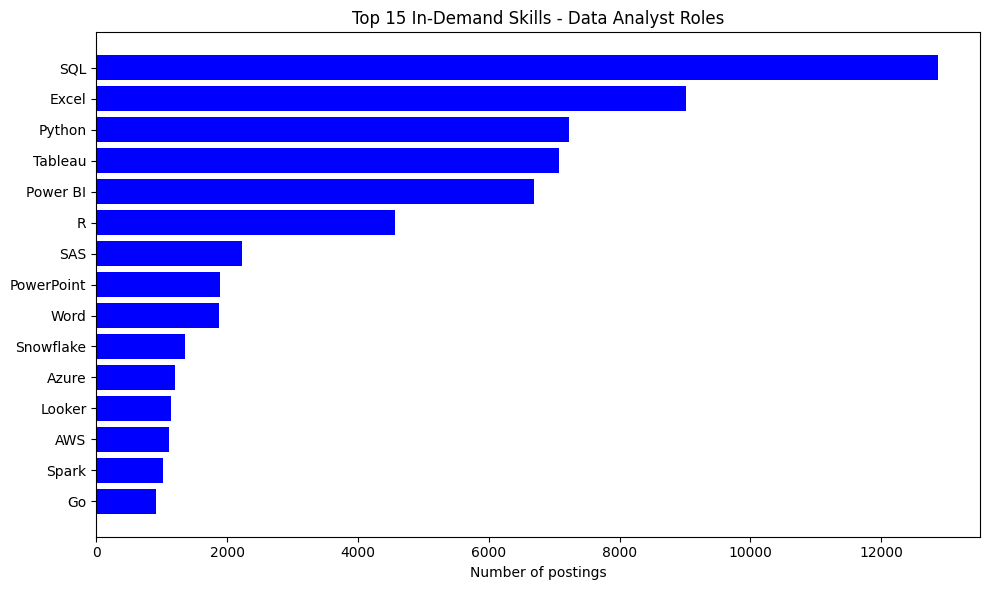

In [25]:
# Sanity-check charts (in python)

import matplotlib.pyplot as plt

top_15 = skill_freq_df.head(15)

plt.figure(figsize=(10, 6))
plt.barh(top_15["skill"], top_15["count"], color="blue")
plt.gca().invert_yaxis()
plt.xlabel("Number of postings")
plt.title("Top 15 In-Demand Skills - Data Analyst Roles")
plt.tight_layout()
plt.savefig("top_skills_chart.png", dpi=150)
plt.show()

In [28]:
# Cleaned job-level data (one row per posting, skills as a comma-separated string)
df_export = df.copy()
df_export["skills_clean_str"] = df_export["skills_clean"].apply(lambda x: ", ".join(x))
df_export.drop(columns=["skills_list", "skills_clean"]).to_csv("cleaned_jobs.csv", index=False)

# Skill frequency table
skill_freq_df.to_csv("skill_frequency.csv", index=False)

# Skill co-occurrence table
top_pairs.to_csv("skill_pairs.csv", index=False)

# Long format: one row per (posting, skill)
long_format = df_export[["title", "company_name", "location", "search_term", "skills_clean"]].explode("skills_clean")
long_format = long_format.rename(columns={"skills_clean": "skill"})
long_format.to_csv("jobs_skills_long.csv", index=False)

In [27]:
# Download files
from google.colab import files
files.download("cleaned_jobs.csv")
files.download("skill_frequency.csv")
files.download("skill_pairs.csv")
files.download("jobs_skills_long.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [30]:
print(f"Postings analyzed: {len(df)}")
print(f"Unique skills found: {skill_freq_df['skill'].nunique()}")
top = skill_freq_df.iloc[0]
print(f"Top skill: {top['skill']} — {top['pct_of_postings']}%")

Postings analyzed: 19039
Unique skills found: 107
Top skill: SQL — 67.6%
